# Paramteric Instabilities
### Caroline Capuano
### Final Project

## <span style="color:pink"> What are parametric instabilities?

Parametric instabilities, or PI's, are a three-mode optomechanical feedback loop that can lead to instability. The three-modes involved are: the fundamental mode from the main laser $\omega_0$, acoustic mode of mirror $\omega_m$, and the higher order scattered sidebands $\omega_n$. The higher order scattered sidebands are created by the scattering of the main laser off of the vibrating mirror. After cycling through the cavity again, the high-order mode will return back to the mirror, and couple with the vibrating mechanical mode of the mirror and the fundamental mode of the main laser. This three mode interaction will produce a radiation pressure force back onto the mirror.

$$F_{\text{rad}} = \dfrac{2}{c} E_{\text{pump}}^* \sum_{n=0}^\infty B_{m,n} E_{\text{return, n}}$$

Instability occurs when the energy from this radiation pressure force exceeds the mechanical dissipation of the mirror $^{[5]}$. This will cause an exponential growth of the acoustic modes, which can eventually lead to a lock loss of the cavity. The instability occurs when the **parametric gain** exceeds 1 (see parametric gain section). Blair descirbes this phenonenom as an "uncontrolled laser powered amplification of acoustic vibrations of the mirrors"$.^{[1]}$

To help understand this phenonenom, you can think of parametric instabilities as a 4 step feedback process:
1. When the pump field is reflect off of the mirror, the mirror's acoustic mode scatters the carrier light into a tranverse higher order optical mode.
2. The higher order mode (HOM) gets amplified by the arm cavity
3. The beating between the carrier and the higher-order mode produces a radiation-pressure force back on the mirror.
4. If the feedback is strong enough, the acoustic mode amplitude will grow exponentially

<div style="text-align: center;">

<img src="3_mode_pi_loop.png" alt="Arm Cavity" width="400">

<p style="font-size: 12px;">Figure 1: Feedback loop from Schiworski **add citation here and in bib** <sup>[5]</sup></p>

</div>

For the radiation pressure force to be great enough to cause instability, certain conditions must be met. This notebook will look into each step of this feedback loop and consider how the geometric conditions of the modes, the power of the cavity, and the quality factor of the optic will impact the instability. 

#### Why is this something high power fabry perot cavities need to be concerned about? 

In order to acheive a low enough sensitivity to detect gravitational waves, the optical power in the arm cavities must be very high. (For reference, LIGO's arm cavity reaches 1 MW.) With an arm cavity with that high of power, the produced radiation pressure force significantly alters the behavor of these optical cavities by producing this unstable feedback loop. Therefore, parametric instabilities can be seen as a **power-limiting** instability; At high enough power, acoustic modes of the mirror can ring up uncontrollably and can cause the interferometer to loose lock. But, to acheive a high enough sensitivity you need a *high* power cavity, so PI's are a barrier to our sensitivity level if left undamped $^{[1]}$. Since we need a high power cavity to detect gravitational waves, then these amplified modes must be damped. 

This was theorized to be a potential issue for high power fabry-perot cavities in 2001 $^{[6]}$. 

We'll explore how these modes are mitigated in LIGO later. We must first understand each part of this feedback loop that produces this instability and what conditions are needed to cause this unstable gain.

### <span style="color:lightblue">Mechanical and Acoustic Modes
Mechanical modes are the natural patterns of vibration that a solid object, like a mirror, can sustain. Every object has a discrete set of these patterns, each with its own characteristic frequency and shape. For example, when you strike a wine glass it rings at a specific pitch — that's its fundamental mechanical mode. 

A LIGO test mass is no different and has thousands of distinct vibrational patterns spread across a wide frequency range. Each mode is characterized by two things: the eigenfrequency $\omega_m$ of the mode, and the mode shape $\vec{u}_m(\vec{r})$. The eigenfrequencies are the resonant frequencies of the given mode, and the mode shape describes which parts of the mirror surface move outward, which move inward, and which remain stationary at the nodes. 

Two of the lower order mechanical modes are:
- Drumhead mode
- Butterfly modes

**INSERT PICTURES FROM PAPER**

### <span style="color:orange">Step 1: Scattering Carrier Light
While the mirror is vibrating the mechanical modes, it is also reflecting the main laser beam (a.k.a "pump field") that circulates in the arm cavity. A good input/main laser beam should be gaussian in shape, the pump field will have a fundamental mode $f_0$. Because the mirror has that small vibration (a.k.a displacement), the reflecting field of the pump field is phase-modulates when reflected off of the mirror. 

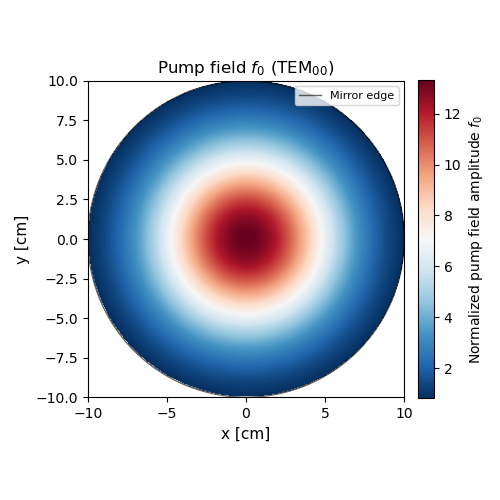

In [ ]:
#| "tags": [ "hide-input",]

import numpy as np
import matplotlib.pyplot as plt

N = 300                 # resolution
mirror_r = 0.1          # mirror radius [m]
beam_waist = 0.06       # beam waist [m]

x = np.linspace(-mirror_r, mirror_r, N)
dx = x[1] - x[0]
dA = dx**2

xx, yy = np.meshgrid(x, x)               # meshgrid coordinates
r = np.sqrt(xx**2 + yy**2)               # radial coordinate
mask = r <= mirror_r                     # only keep points on the mirror

def gaussian_beam(xx, yy, beam_waist, mask=None):
    """
    Create the normalized amplitude of the pump field (TEM00 Gaussian beam).
    """
    f = np.exp(-(xx**2 + yy**2) / beam_waist**2)

    if mask is not None:
        f = np.where(mask, f, 0.0)

    norm = np.sqrt(np.sum(f**2) * dA)
    f /= norm
    return f

f0 = gaussian_beam(xx, yy, beam_waist, mask=mask)
f0_display = f0.copy()
f0_display[~mask] = np.nan

axis_lim = [
    -mirror_r * 100, mirror_r * 100,   # x limits in cm
    -mirror_r * 100, mirror_r * 100    # y limits in cm
]

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_facecolor('none')

im = ax.imshow(
    f0_display,
    extent=axis_lim,
    origin='lower',
    cmap='RdBu_r'
)

theta = np.linspace(0, 2 * np.pi, 300)

ax.plot(
    mirror_r * 100 * np.cos(theta),    # mirror edge in cm
    mirror_r * 100 * np.sin(theta),
    'k-',
    lw=1.0,
    alpha=0.6,
    label='Mirror edge'
)

plt.colorbar(
    im,
    ax=ax,
    label=r'Normalized pump field amplitude $f_0$',
    fraction=0.046,
    pad=0.04
)

ax.set_xlabel('x [cm]', fontsize=11)
ax.set_ylabel('y [cm]', fontsize=11)
ax.set_title(r'Pump field $f_0$ (TEM$_{00}$)', fontsize=12)
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('pump_field.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

Quoting *Parametric Oscillatory Instability in Fabry-Perot (FP) Interferometer* $^{[6]}$, "small mechanical oscillations with the resonance frequency $\omega_m$ modulate the distance L that causes the exitation optical fields with frequencies $\omega_0 \pm \omega_m$.

<details>
<summary><b>Click to expand derivation of the sidebands from a vibrating mirror</b></summary>

We take the incident field to be

$$
E_{\rm in}(t)=E_0 e^{i\omega_0 t},
$$

and let the mirror surface vibrate as

$$
x(t)=x_m \cos(\omega_m t).
$$

Reflection from a moving mirror adds a phase shift proportional to the changing optical path length, so the reflected field is

$$
E_{\rm r}(t)\propto E_0 e^{i\omega_0 t} e^{\,i\,2k x(t)},
\qquad
k=\frac{2\pi}{\lambda_0}.
$$

Substituting \(x(t)\) gives

$$
E_{\rm r}(t)\propto E_0 e^{i\omega_0 t} e^{\,i\,2k x_m \cos(\omega_m t)}.
$$

For small motion, $2k x_m \ll 1$, expand the exponential to first order:

$$
e^{i\,2k x_m \cos(\omega_m t)}
\approx
1+i\,2k x_m \cos(\omega_m t).
$$

So,

$$
E_{\rm r}(t)\approx
E_0 e^{i\omega_0 t}
\left[
1+i\,2k x_m \cos(\omega_m t)
\right].
$$

Now use

$$
\cos(\omega_m t)=\frac{1}{2}\left(e^{i\omega_m t}+e^{-i\omega_m t}\right),
$$

which gives

$$
E_{\rm r}(t)\approx
E_0 e^{i\omega_0 t}
\left[
1+i\,2k x_m \cdot \frac{1}{2}\left(e^{i\omega_m t}+e^{-i\omega_m t}\right)
\right].
$$

Simplifying,

$$
E_{\rm r}(t)\approx
E_0 e^{i\omega_0 t}
\left[
1+i k x_m e^{i\omega_m t}+i k x_m e^{-i\omega_m t}
\right].
$$

Distributing the carrier factor $e^{i\omega_0 t}$,

$$
E_{\rm r}(t)\approx
E_0 e^{i\omega_0 t}
+
i k x_m E_0 e^{i(\omega_0+\omega_m)t}
+
i k x_m E_0 e^{i(\omega_0-\omega_m)t}.
$$

So the reflected field contains three frequency components:

$$
\omega_0,
\qquad
\omega_0+\omega_m,
\qquad
\omega_0-\omega_m.
$$

Thus, vibration of the mirror phase-modulates the carrier and produces upper and lower sidebands.

</details>

The reason I wanted to show what the suface distribution should look like is because a key aspect of the scattering is the overlap of the fundamental mode of the laser and the vibrating mechanical mode of the mirror. The overlap between these two modes is what causes the scattered light $B_{m,n}$. If the mechanical mode has a spatial pattern that overlaps with a particular higher order optical mode, energy transfers efficiently into that mode. If the shapes are orthogonal, no scattering will occur into that mode regardless of how strongly the mirror vibrates. 
*If the mechanical mode has a node where the optical mode has an antinode, they cancel out and very little scattering occurs.*

$$ E_{\text{scatt,n}}=\dfrac{2 \pi i}{\lambda_0} A_m E_{\text{pump}} B_{m,n} $$


The scattering produces two new frequency components: an upper sideband ($\omega_o - \omega_m$) and a lower sideband ($\omega_o + \omega_m$), where $\omega_m$ is the mechanical resonance frequency.

#### Scattered light, so what?
What important about these created sidebands is that they are not lower order modes, $\text{TEM}_{00}$. They are **higher order modes**, HOMs, that are dependent on $B_{m,n}$. Because of this, a single mechanical mode can simultaneously scatter light into many different HOMs, each with its own overlap coefficient $B_{m,n}$.

$$B_{m,n} = \iint_{\text{surface}} f_0 \, f_n (\vec{u}_m \cdot \hat{z}) \, d\vec{r}_\perp$$

Once scattered into a HOM, the light doesn't just escape — it keeps circulating in the cavity.

Output()

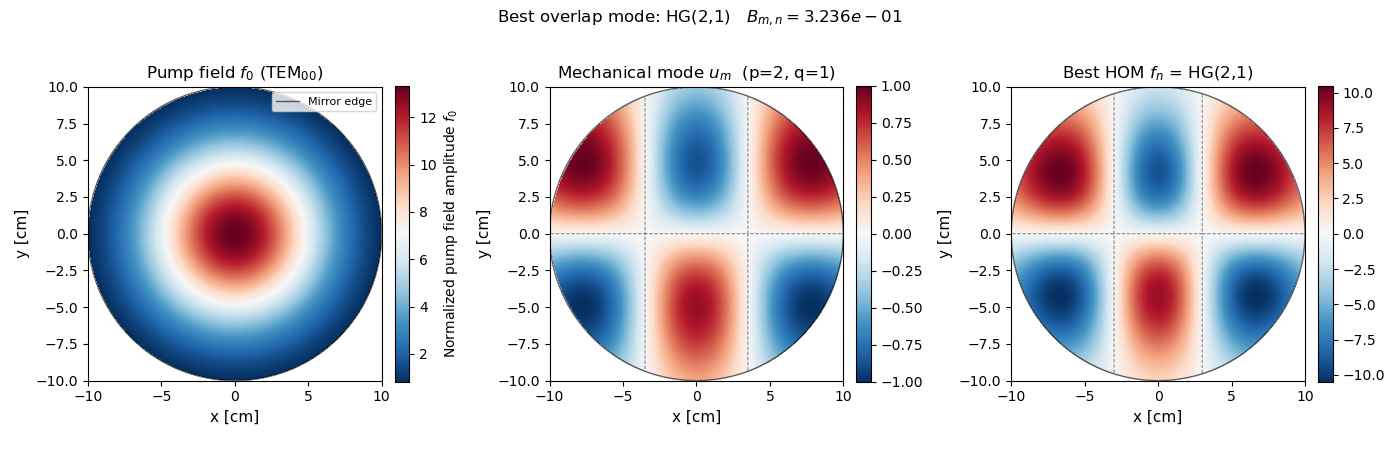

In [ ]:
#| "tags": [ "hide-input",]
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.special import hermite
import ipywidgets as widgets
from IPython.display import display

# ============================================================
# Grid / mirror / beam parameters
# ============================================================
N = 300
mirror_r = 0.10
beam_waist = 0.06

x = np.linspace(-mirror_r, mirror_r, N)
dx = x[1] - x[0]
dA = dx**2

xx, yy = np.meshgrid(x, x)
r = np.sqrt(xx**2 + yy**2)
mask = r <= mirror_r

axis_lim = [
    -mirror_r * 100, mirror_r * 100,
    -mirror_r * 100, mirror_r * 100
]

theta = np.linspace(0, 2 * np.pi, 300)

# ============================================================
# Helper functions
# ============================================================
def signed_norm(arr):
    """Center colormap at zero for signed fields."""
    arr_valid = arr[np.isfinite(arr)]
    vmax = np.max(np.abs(arr_valid)) if arr_valid.size > 0 else 1.0
    if vmax == 0:
        vmax = 1.0
    return TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)


def gaussian_beam(xx, yy, beam_waist, mask=None):
    """
    Create the normalized amplitude of the pump field (TEM00 Gaussian beam).
    """
    f = np.exp(-(xx**2 + yy**2) / beam_waist**2)

    if mask is not None:
        f = np.where(mask, f, 0.0)

    norm = np.sqrt(np.sum(f**2) * dA)
    f /= norm
    return f


def hermite_gauss(p, q, xx, yy, beam_waist, mask=None):
    """
    Normalized Hermite-Gaussian HG(p,q) mode.
    """
    xi = np.sqrt(2) * xx / beam_waist
    eta = np.sqrt(2) * yy / beam_waist

    Hp = hermite(p)(xi)
    Hq = hermite(q)(eta)
    env = np.exp(-(xx**2 + yy**2) / beam_waist**2)

    f = Hp * Hq * env

    if mask is not None:
        f = np.where(mask, f, 0.0)

    norm = np.sqrt(np.sum(f**2) * dA)
    if norm > 0:
        f /= norm

    return f


def mechanical_mode(xx, yy, p_mech, q_mech, mirror_r, mask=None):
    """
    Synthetic mechanical mode shape for visualization.
    """
    scale = 0.7 * mirror_r

    xi = np.sqrt(2) * xx / scale
    eta = np.sqrt(2) * yy / scale

    Hp = hermite(p_mech)(xi)
    Hq = hermite(q_mech)(eta)
    env = np.exp(-(xx**2 + yy**2) / scale**2)

    u = Hp * Hq * env

    if mask is not None:
        u = np.where(mask, u, 0.0)

    maxabs = np.max(np.abs(u))
    if maxabs > 0:
        u /= maxabs

    return u


def compute_best_hom(u_m, f0, max_order=6):
    """
    Search HG modes up to total order = max_order
    and return the one with the largest |B_mn|.
    """
    best_pair = None
    best_B = None
    best_fn = None

    for total_order in range(max_order + 1):
        for p in range(total_order + 1):
            q = total_order - p

            fn = hermite_gauss(p, q, xx, yy, beam_waist, mask=mask)
            integrand = f0 * fn * u_m
            B_mn = np.sum(integrand) * dA

            if (best_B is None) or (abs(B_mn) > abs(best_B)):
                best_B = B_mn
                best_pair = (p, q)
                best_fn = fn

    return best_pair, best_B, best_fn


# ============================================================
# Fixed fundamental mode
# ============================================================
f0 = gaussian_beam(xx, yy, beam_waist, mask=mask)
f0_display = f0.copy()
f0_display[~mask] = np.nan

# ============================================================
# Initial mode choices
# ============================================================
p0, q0 = 2, 1
u0 = mechanical_mode(xx, yy, p0, q0, mirror_r, mask=mask)
(best_pq, best_B, best_fn) = compute_best_hom(u0, f0, max_order=6)
pb, qb = best_pq

# ============================================================
# Figure setup
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

def draw_fundamental(ax):
    ax.clear()
    ax.set_facecolor('none')

    im = ax.imshow(
        f0_display,
        extent=axis_lim,
        origin='lower',
        cmap='RdBu_r'   # keep same as your original code
    )

    ax.plot(
        mirror_r * 100 * np.cos(theta),
        mirror_r * 100 * np.sin(theta),
        'k-',
        lw=1.0,
        alpha=0.6,
        label='Mirror edge'
    )

    ax.set_xlabel('x [cm]', fontsize=11)
    ax.set_ylabel('y [cm]', fontsize=11)
    ax.set_title(r'Pump field $f_0$ (TEM$_{00}$)', fontsize=12)
    ax.set_aspect('equal')
    ax.legend(fontsize=8, loc='upper right')
    return im


def draw_mechanical(ax, u_m, p_mech, q_mech):
    ax.clear()
    ax.set_facecolor('none')

    u_display = u_m.copy()
    u_display[~mask] = np.nan

    im = ax.imshow(
        u_display,
        extent=axis_lim,
        origin='lower',
        cmap='RdBu_r',
        norm=signed_norm(u_display)
    )

    ax.plot(
        mirror_r * 100 * np.cos(theta),
        mirror_r * 100 * np.sin(theta),
        'k-',
        lw=1.0,
        alpha=0.6
    )

    ax.contour(
        x * 100, x * 100, u_display,
        levels=[0],
        colors='k',
        linewidths=0.7,
        linestyles='--',
        alpha=0.5
    )

    ax.set_xlabel('x [cm]', fontsize=11)
    ax.set_ylabel('y [cm]', fontsize=11)
    ax.set_title(rf'Mechanical mode $u_m$  (p={p_mech}, q={q_mech})', fontsize=12)
    ax.set_aspect('equal')
    return im


def draw_best_hom(ax, fn_best, pb, qb):
    ax.clear()
    ax.set_facecolor('none')

    fn_display = fn_best.copy()
    fn_display[~mask] = np.nan

    im = ax.imshow(
        fn_display,
        extent=axis_lim,
        origin='lower',
        cmap='RdBu_r',
        norm=signed_norm(fn_display)
    )

    ax.plot(
        mirror_r * 100 * np.cos(theta),
        mirror_r * 100 * np.sin(theta),
        'k-',
        lw=1.0,
        alpha=0.6
    )

    ax.contour(
        x * 100, x * 100, fn_display,
        levels=[0],
        colors='k',
        linewidths=0.7,
        linestyles='--',
        alpha=0.5
    )

    ax.set_xlabel('x [cm]', fontsize=11)
    ax.set_ylabel('y [cm]', fontsize=11)
    ax.set_title(rf'Best HOM $f_n$ = HG({pb},{qb})', fontsize=12)
    ax.set_aspect('equal')
    return im


# initial draw
im0 = draw_fundamental(axes[0])
im1 = draw_mechanical(axes[1], u0, p0, q0)
im2 = draw_best_hom(axes[2], best_fn, pb, qb)

# colorbars
cbar0 = fig.colorbar(
    im0, ax=axes[0],
    label=r'Normalized pump field amplitude $f_0$',
    fraction=0.046, pad=0.04
)
cbar1 = fig.colorbar(
    im1, ax=axes[1],
    fraction=0.046, pad=0.04
)
cbar2 = fig.colorbar(
    im2, ax=axes[2],
    fraction=0.046, pad=0.04
)

fig.suptitle(
    rf'Best overlap mode: HG({pb},{qb})   $B_{{m,n}} = {best_B:.3e}$',
    fontsize=12
)

plt.tight_layout()

# ============================================================
# Update function
# ============================================================
def update(p_mech, q_mech):
    global cbar1, cbar2

    u_m = mechanical_mode(xx, yy, p_mech, q_mech, mirror_r, mask=mask)
    (pb, qb), B_val, fn_best = compute_best_hom(u_m, f0, max_order=6)

    # remove old colorbars for panels 2 and 3
    cbar1.remove()
    cbar2.remove()

    # redraw panels 2 and 3 completely
    im1_new = draw_mechanical(axes[1], u_m, p_mech, q_mech)
    im2_new = draw_best_hom(axes[2], fn_best, pb, qb)

    # add updated colorbars back
    cbar1 = fig.colorbar(
        im1_new, ax=axes[1],
        fraction=0.046, pad=0.04
    )
    cbar2 = fig.colorbar(
        im2_new, ax=axes[2],
        fraction=0.046, pad=0.04
    )

    fig.suptitle(
        rf'Best overlap mode: HG({pb},{qb})   $B_{{m,n}} = {B_val:.3e}$',
        fontsize=12
    )

    fig.canvas.draw_idle()


# ============================================================
# Sliders
# ============================================================
slider_p = widgets.IntSlider(
    value=p0, min=0, max=5, step=1,
    description='p (mech)',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='350px')
)

slider_q = widgets.IntSlider(
    value=q0, min=0, max=5, step=1,
    description='q (mech)',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='350px')
)

label = widgets.HTML(
    value='<b>Mechanical mode indices:</b> p = number of x-like nodal features, q = number of y-like nodal features'
)

ui = widgets.VBox([
    label,
    widgets.HBox([slider_p, slider_q])
])

out = widgets.interactive_output(
    update,
    {'p_mech': slider_p, 'q_mech': slider_q}
)

display(ui, out)

### <span style="color:lightcoral">Step 2: HOM Amplification



The circulation of the sidebands in the cavity will cause them to pick up a phase each round trip ($\phi_{\text{total}} = \phi_{\text{prop}} + \phi_{\text{gouy}}$, where $\phi_{\text{prop}} = \dfrac{4 \pi f L}{c}$ and $\phi_{\text{gouy}} = n \phi_G$). Let's look at the cavity:



The scattering and mirror matrixes are not difficult at all, just model a simple fabry-perot cavity with the HOM sidebands circulating.


<div style="text-align: center;">

<img src="pi_cavity_w_drumhead.png" alt="Directed graph" width="400"/>

<p style="font-size: 12px;"></p>

</div>


Let's work out the path of the sidebands in the cavity. After being reflected off of the vibrating mirror, the sidebands will propagate across the cavity and reflect off of the other mirror. After this end reflection, the field will progagate across the length of the cavity once again until reaching the vibrating mirror for the third time.

<div style="text-align: center;">

![Path in Cavity From *A General Approach to Optomechanical Parametric Instabilities*](cavity_equation.png)

<p style="font-size: 12px;">Path in Cavity From "A General Approach to Optomechanical Parametric Instabilities" <sup>[2]</sup></p>

</div>

Graph representation:

<div style="text-align: center;">

<img src="pi_directed_graph_cavity.png" alt="Directed graph" width="700"/>

<p style="font-size: 12px;"></p>

</div>

Like we've done countless times in this class, let's now put together the scattering matrix so that we can calculate the gain from this cavity amplificiation: $G_n^{\pm} = \vec{e}_x^T(\mathbb{I}-S_n^{\pm})^{-1}\vec{e}_x$ where $\vec{e}_x$ is the basis vector and $S_n^{\pm}$ is the scattering matrix. 

**INSERT EQUATIONS**

The scattering matrix:

$$
S^{\pm}_n=
\begin{pmatrix}
0 & 0 & 0 & 0 & 0 \\\\
t_A & 0 & 0 & 0 & -r_A \\\\
0 & e^{i(\phi_n \pm \dfrac{\omega_m L}{c})} & 0 & 0 & 0 \\\\
0 & 0 & -r_B & 0 & 0 \\\\
0 & 0 & 0 & e^{i(\phi_n \pm \dfrac{\omega_m L}{c})} & 0 \\\\
\end{pmatrix}
$$

Now lets subtract the identity matrix $\mathbb{I}$ by the scattering matrix:

$$
\mathbb{I} - S^{\pm}_n=
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 \\\\
t_A & 1 & 0 & 0 & -r_A \\\\
0 & e^{i(\phi_n \pm \dfrac{\omega_m L}{c})} & 1 & 0 & 0 \\\\
0 & 0 & -r_B & 1 & 0 \\\\
0 & 0 & 0 & e^{i(\phi_n \pm \dfrac{\omega_m L}{c})} & 1 \\\\
\end{pmatrix}
$$

Now let's invert the matrix to get our transfer functions:

$$
(\mathbb{I} - S^{\pm}_n)^{-1}=
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 \\\\
\dfrac{t_A}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{r_A r_Be^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_A e^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_A}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} \\\\
\dfrac{t_Ae^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{e^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_A e^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_A e^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} \\\\
-\dfrac{t_A r_Be^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_Be^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}& -\dfrac{r_B}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{r_A r_Be^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} \\\\
-\dfrac{t_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & -\dfrac{r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{e^{i(\phi_n \pm \dfrac{\omega_m L}{c})}}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} & \dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}} \\\\
\end{pmatrix}
$$


So our amplification from the cavity is:

$$
G_n^{\pm} = \vec{e}_x^T(\mathbb{I}-S_n^{\pm})^{-1}\vec{e}_x = 
\begin{pmatrix}
E_{\text{refl, mirror}} & E_{\text{cav, 0}} & E_{\text{cav, 1}} & E_{\text{cav, 2}} & E_{\text{cav, 3}} & E_{\text{cav, 4}}
\end{pmatrix}
(\mathbb{I} - S^{\pm}_n)^{-1}
\begin{pmatrix}
E_{\text{refl, mirror}} \\\\
E_{\text{cav, 0}} \\\\
E_{\text{cav, 1}} \\\\
E_{\text{cav, 2}} \\\\
E_{\text{cav, 3}} \\\\
E_{\text{cav, 4}} \\\\

\end{pmatrix}
$$


<!-- $$E_{\text{refl}} = r_1E_{\text{in}} + t_1E_{\text{cav2}} = \boxed{\dfrac{r_1 - r_2e^{2ikL}}{1-r_1r_2e^{2ikL}} E_{\text{in}}}$$
$$E_{\text{cav}} = t_1E_{\text{in}} + (-r_1e^{ikL})(-r_2e^{ikL})E_{\text{cav}} = \boxed{\dfrac{t_1}{1-r_1r_2e^{2ikL}} E_{\text{in}}}$$
$$E_{\text{cav2}} = -r_2e^{ikL} E_{\text{cav}} = \boxed{\dfrac{-r_2e^{ikL} t_1}{1-r_1r_2e^{2ikL}} E_{\text{in}}}$$
$$E_{\text{trans}} = $$ -->

What transfer function are we interested in? We want the gain from traveling through the cavity. So, we should look at the transfer function from the electric field directly after scattering $E_{\text{in}}$ to the electric field just before reaching the mirror again. The particular transfer function is then 

$$\boxed{\dfrac{E_{\text{refl, mirror}}}{E_{\text{cav, 4}}} = \dfrac{1}{1-r_A r_Be^{2i(\phi_n \pm \dfrac{\omega_m L}{c})}}}$$


Using this equation, $G_n = G^-_n-G^{+*}_n$, we can calculate teh gain coefficient of the cavity.

$$
\boxed{G_n = G^-_n-G^{+*}_n = \dfrac{1}{1-r_A r_Be^{2i(\phi_n - \dfrac{\omega_m L}{c})}} - \dfrac{1}{1-r_A r_Be^{-2i(\phi_n + \dfrac{\omega_m L}{c})}}} 
$$

<!-- $$G_n^\pm = \boxed{\dfrac{t_A}{1-r_Ar_Be^{i\phi_{total}^\pm}}} = \boxed{\dfrac{t_A}{1-r_Ar_Be^{i(\dfrac{2(\omega_0 \pm \omega_m)L}{c} - n \phi_{G, rt})}}}$$ -->

Let's try adding some parameters so that we can solve the real part of this transfer function (this is what is needed to calculated $B_{m,n}$). Parameters were taken from $\text{Miller, John, et al}^{[4]}$.


| Parameter (LIGO) |  Value |
|---------------|-----------------|
| Cavity Length [m] | 3994.5 |
| Input Mirror transmittance | 0.014 |
| End Mirror transmittance | $10^{-5}$ |
| Frequency of mode $\omega_m$ [Hz] | 29950 |
| Phase $\phi_n$ [rad] |             |


2.722713633111154
G_minus = 0.5018+0.0487j
G_plus  = 0.5439+2.4432j
Gn      = -0.0421+2.4919j
Re[Gn]  = -0.0421


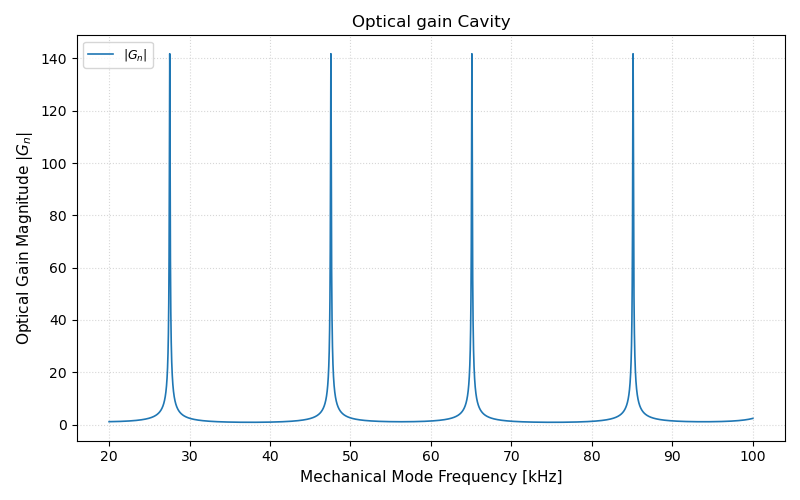

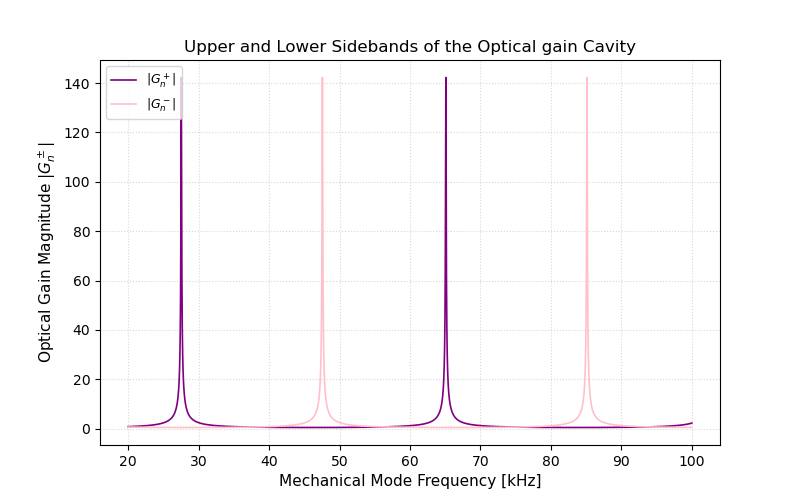

In [6]:
c       = 3e8   # speed of light [m/s]
L       = 3994.5  # cavity length [m]

T_I     = 0.014 # input mirror power transmissivity
T_E     = 1e-5   # end mirror power transmissivity
r_A     = np.sqrt(1 - T_I)
r_B     = np.sqrt(1 - T_E)

phi_G   = np.deg2rad(156)  # round-trip Gouy phase [rad]
print(phi_G)
n       = 2    # HOM order  (p + q)
phi_n   = -n * phi_G   # round-trip HOM phase [rad]

f = 29950 # eigenfreqency of mode [Hz]
omega_m = 2 * np.pi * f  # mechanical mode frequency [rad/s]

G_minus = 1 / (1 - r_A * r_B * np.exp( 2j * (phi_n - omega_m * L / c)))
G_plus  = 1 / (1 - r_A * r_B * np.exp( 2j * (phi_n + omega_m * L / c)))

Gn = G_minus - np.conj(G_plus)

print(f"G_minus = {G_minus:.4f}")
print(f"G_plus  = {G_plus:.4f}")
print(f"Gn      = {Gn:.4f}")
print(f"Re[Gn]  = {Gn.real:.4f}")



f = np.linspace(20e3, 100e3, 50000)        # frequency array [Hz]
omega_m = 2 * np.pi * f                   # array [rad/s]

G_minus = 1 / (1 - r_A * r_B * np.exp(2j * (phi_n - omega_m * L / c)))
G_plus  = 1 / (1 - r_A * r_B * np.exp(2j * (phi_n + omega_m * L / c)))
Gn      = G_minus - np.conj(G_plus)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(f / 1e3, np.abs(G_plus),  lw=1.2, label=rf'$|G^+_n|$', color='purple')
ax1.plot(f / 1e3, np.abs(G_minus), lw=1.2, label=rf'$|G^-_n|$', color = 'pink')
ax1.set_title('Upper and Lower Sidebands of the Optical gain Cavity', fontsize=12)
ax1.set_xlabel('Mechanical Mode Frequency [kHz]', fontsize=11)
ax1.set_ylabel(rf'Optical Gain Magnitude $|G^\pm_n|$', fontsize=11)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, linestyle=':', alpha=0.5)

fig, ax2 = plt.subplots(figsize=(8, 5))

ax2.plot(f / 1e3, np.abs(Gn),      lw=1.2, label=rf'$|G_n|$')
ax2.set_xlabel('Mechanical Mode Frequency [kHz]', fontsize=11)
ax2.set_title('Optical gain Cavity', fontsize=12)

ax2.set_ylabel(rf'Optical Gain Magnitude $|G_n|$', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()



Output()

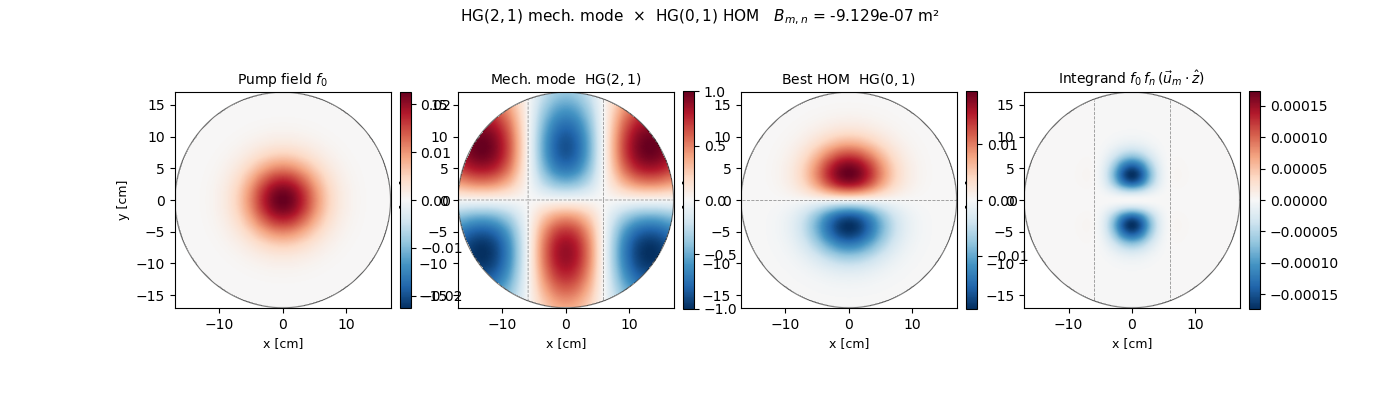

In [10]:
%matplotlib widget
"""
Interactive Stage 1 — Scattering overlap integral map.

Sliders for p_mech and q_mech update the mechanical mode,
best-overlap HOM, and integrand panels in real time.

Run in a Jupyter notebook with:
    %matplotlib widget        ← in the first cell

Reference: Evans, Barsotti, Fritschel (2009), arXiv:0910.2716
           Blair PhD thesis, UWA (2017)
"""

# ── put  %matplotlib widget  in the cell above this one ──────────

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.special import hermite
import ipywidgets as widgets
from IPython.display import display

# ─────────────────────────────────────────────────────────────────
# 1.  Grid and mirror parameters
# ─────────────────────────────────────────────────────────────────
N          = 200        # lower res for faster interaction
mirror_r   = 0.17       # mirror radius [m]
beam_waist = 0.06       # 1/e^2 beam radius [m]

x = np.linspace(-mirror_r, mirror_r, N)
X, Y = np.meshgrid(x, x)
R    = np.sqrt(X**2 + Y**2)
mask = R <= mirror_r
dA   = (x[1] - x[0])**2
extent = [-mirror_r*100, mirror_r*100, -mirror_r*100, mirror_r*100]
theta  = np.linspace(0, 2*np.pi, 300)

# ─────────────────────────────────────────────────────────────────
# 2.  Field functions  (unchanged from previous scripts)
# ─────────────────────────────────────────────────────────────────

def gaussian_beam(X, Y, w0):
    """TEM00 pump field amplitude (real, normalised)."""
    f = np.exp(-(X**2 + Y**2) / w0**2)
    f /= np.sqrt(np.sum(f**2))
    return f


def hermite_gauss(p, q, X, Y, w0):
    """HG_{pq} field amplitude (signed, normalised)."""
    xi  = np.sqrt(2) * X / w0
    eta = np.sqrt(2) * Y / w0
    Hp  = hermite(p)(xi)
    Hq  = hermite(q)(eta)
    env = np.exp(-(X**2 + Y**2) / w0**2)
    f   = Hp * Hq * env
    return f / (np.sqrt(np.sum(f**2)) + 1e-30)


def mechanical_mode(X, Y, p_mech, q_mech):
    """
    Synthetic drumhead mode  u_m . z_hat  (normalised to [-1, 1]).
    Replace with np.load('fem_mode.npy') for real FEM data.
    """
    scale = mirror_r * 0.7
    xi    = np.sqrt(2) * X / scale
    eta   = np.sqrt(2) * Y / scale
    Hp    = hermite(p_mech)(xi)
    Hq    = hermite(q_mech)(eta)
    env   = np.exp(-(X**2 + Y**2) / scale**2)
    u     = Hp * Hq * env
    return u / (np.max(np.abs(u)) + 1e-30)


def signed_norm(arr):
    """TwoSlopeNorm centred on 0 for signed arrays."""
    valid = arr[~np.isnan(arr)]
    vmax  = np.max(np.abs(valid)) + 1e-30 if len(valid) > 0 else 1.0
    return TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)


def compute_best_hom(u_m, f0):
    """Find HOM with largest |B_{m,n}| given mechanical mode u_m."""
    hom_pairs = [(p, q) for n in range(6)
                         for p in range(n + 1)
                         for q in [n - p]]
    B = {}
    for (p, q) in hom_pairs:
        fn               = hermite_gauss(p, q, X, Y, beam_waist)
        integrand        = f0 * fn * u_m
        integrand[~mask] = 0.0
        B[(p, q)]        = np.sum(integrand) * dA
    best = max(B, key=lambda k: abs(B[k]))
    return best, B[best]


# ─────────────────────────────────────────────────────────────────
# 3.  Pre-compute fixed pump field
# ─────────────────────────────────────────────────────────────────
f0 = gaussian_beam(X, Y, beam_waist)

# ─────────────────────────────────────────────────────────────────
# 4.  Build figure with four panels
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
plt.subplots_adjust(top=0.88, bottom=0.12)

titles_fixed = [
    r'Pump field $f_0$',
    r'Mechanical mode $\vec{u}_m \cdot \hat{z}$',
    r'Best-overlap HOM $f_n$',
    r'Integrand $f_0\,f_n\,(\vec{u}_m \cdot \hat{z})$'
]

# initialise with p=2, q=1
p0, q0    = 2, 1
u_m_init  = mechanical_mode(X, Y, p0, q0)
(pb, qb), B_val = compute_best_hom(u_m_init, f0)
fn_init   = hermite_gauss(pb, qb, X, Y, beam_waist)
intg_init = f0 * fn_init * u_m_init
intg_init[~mask] = 0.0

init_arrays = [f0, u_m_init, fn_init, intg_init]
ims, cbs = [], []

for ax, arr, title in zip(axes, init_arrays, titles_fixed):
    disp        = arr.copy()
    disp[~mask] = np.nan
    im = ax.imshow(disp, extent=extent, origin='lower',
                   cmap='RdBu_r', norm=signed_norm(disp))
    ax.plot(mirror_r*100*np.cos(theta),
            mirror_r*100*np.sin(theta),
            'k-', lw=0.8, alpha=0.5)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x [cm]', fontsize=9)
    ax.set_ylabel('y [cm]', fontsize=9)
    ax.set_aspect('equal')
    ims.append(im)
    cbs.append(cb)

fig.suptitle(
    rf'Stage 1 — overlap integrand   '
    rf'HG$({p0},{q0})$ mech. mode  ×  HG$({pb},{qb})$ HOM   '
    rf'$B_{{m,n}}$ = {B_val:.3e} m²',
    fontsize=11)

# ─────────────────────────────────────────────────────────────────
# 5.  Update function called by sliders
# ─────────────────────────────────────────────────────────────────
def update(p_mech, q_mech):
    u_m = mechanical_mode(X, Y, p_mech, q_mech)
    (pb, qb), B_val = compute_best_hom(u_m, f0)
    fn_best        = hermite_gauss(pb, qb, X, Y, beam_waist)
    integrand_best = f0 * fn_best * u_m
    integrand_best[~mask] = 0.0

    new_arrays = [f0, u_m, fn_best, integrand_best]
    new_titles = [
        r'Pump field $f_0$',
        rf'Mech. mode  HG$({p_mech},{q_mech})$',
        rf'Best HOM  HG$({pb},{qb})$',
        r'Integrand $f_0\,f_n\,(\vec{u}_m \cdot \hat{z})$'
    ]

    for ax, im, arr, title in zip(axes, ims, new_arrays, new_titles):
        disp        = arr.copy()
        disp[~mask] = np.nan
        norm        = signed_norm(disp)
        im.set_data(disp)
        im.set_norm(norm)
        ax.set_title(title, fontsize=10)
        # redraw nodal contours
        for coll in ax.collections:
            coll.remove()
        ax.contour(x*100, x*100, disp, levels=[0],
                   colors='k', linewidths=0.6, linestyles='--', alpha=0.4)

    fig.suptitle(
        rf'HG$({p_mech},{q_mech})$ mech. mode  ×  HG$({pb},{qb})$ HOM   '
        rf'$B_{{m,n}}$ = {B_val:.3e} m²',
        fontsize=11)
    fig.canvas.draw_idle()

# ─────────────────────────────────────────────────────────────────
# 6.  Sliders
# ─────────────────────────────────────────────────────────────────
slider_p = widgets.IntSlider(
    value=2, min=0, max=5, step=1,
    description=r'p (mech)',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='400px'))

slider_q = widgets.IntSlider(
    value=1, min=0, max=5, step=1,
    description=r'q (mech)',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='400px'))

label = widgets.HTML(
    value='<b>Mechanical mode order:</b>  '
          'p = nodal lines in x,  q = nodal lines in y')

ui = widgets.VBox([
    label,
    widgets.HBox([slider_p, slider_q])
])

out = widgets.interactive_output(update, {'p_mech': slider_p,
                                          'q_mech': slider_q})
display(ui, out)

### <span style="color:#CD5C5C"> Step 3: Radiation Pressure
After the scattered HOM is amplified after circulating around the cavity, it will reflect off of the same mirror surface and interferes with the pump field. This is where the magic happens. The optical field can couple back into the mechanical mode. But, instead of scattering, this interaction will cause a radiation pressure force on the mirror. If the phase is right, this force drives the mechanical mode further — amplifying the original vibration rather than damping it. The mirror then scatters more light, which gets amplified, which pushes the mirror harder. 

$$F_{\text{rad}} = \dfrac{2}{c} E_{\text{pump}}^* \sum_{n=0}^\infty B_{m,n} E_{\text{return, n}}$$


### <span style="color:#FF474C"> Step 4: Instability

The parametric gain is how we understand how strongly the mode interaction drives the acoustic mode. Think of it like a threshold: consider the ratio of the radiation-pressure ennergy fed into the mode to the mechaincal energy the mode looses by damping. If the parametric gain is less than one, the the mode damping is dominating; if the parametric gain is equal to one, it is at the instability threshold; if the gain is greater than one, then the mode rings up and becomes unstable:
 - <span style="color:green">R_m &lt; 1 : the mode is damped</span> 
 - $R_m$ = 1 : intability threshold
 - <span style="color:red">R_m &gt; 1 : the mode rings up</span> 


Parametric gain equation:

$R_m = \dfrac{4 \pi Q_m P_{\text{circ}}}{M \omega^2_m c \lambda_0} \sum_{n=0}^\infty \mathbb{R}[G_n]B^2_{m,n}$

The parametric gain is directly portional to the power $P_{\text{circ}}$, the spatial overlap between the optical and mechanical mode $B_{m,n}$, and the mechaincal mode $Q_m$. This describes how long it rings before friction damps it out. This can be estimated by the sum of the loss for each part of the $\text{mirror}^{[1]}$

$$Q_m = \dfrac{1}{\phi_{\text{total}}}; \quad \text{where} \space \space\phi_{\text{total}} = \phi_{\text{substrate}} + \phi_{\text{coating}} + \phi_{\text{geometry}}+\phi_{\text{suspension}}$$

Let's build off of the previous parameters so that we can calculate the parametric gain caused by this 3 mode interaction.

| Parameter (LIGO) |  Value |
|---------------|-----------------|
| Power of Cavity [MW]| 1 |
| Mechanical Mode Quality Factor ($Q_m$)|  $10^7$    |
| Mirror Mass [kg]|  40   |
| Frequency of Mechanical Mode $f_m$[Hz] | 29950 |
| Spatial Overlap $B_{m,n}$| 0.21 |


Output()

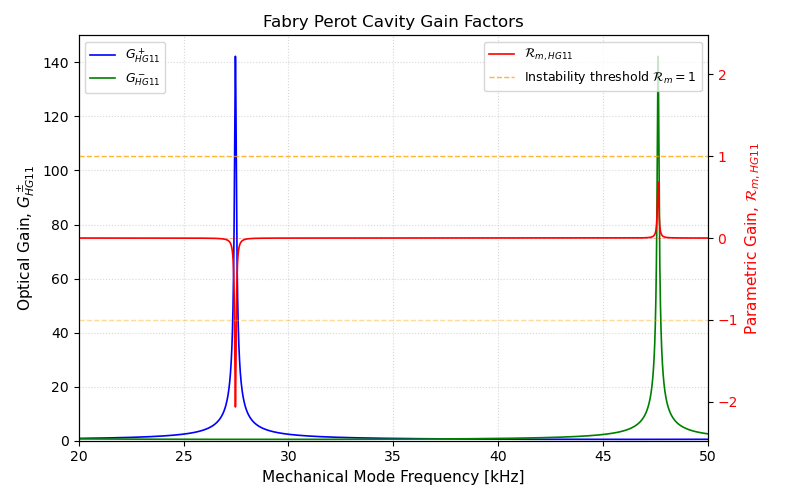

In [17]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


c     = 3e8
L     = 3994.5
T_I   = 0.014
T_E   = 1e-5
r_A   = np.sqrt(1 - T_I)
r_B   = np.sqrt(1 - T_E)
M     = 40
lam   = 1064e-9
phi_G = 2.72
n     = 2
phi_n = -n * phi_G

f_m     = np.linspace(20e3, 50e3, 50000)
omega_m = 2 * np.pi * f_m

fig, ax1 = plt.subplots(figsize=(8, 5))

line_Gplus,  = ax1.plot([], [], color='blue',  lw=1.2, label=r'$G^+_{HG11}$')
line_Gminus, = ax1.plot([], [], color='green', lw=1.2, label=r'$G^-_{HG11}$')
ax1.set_xlabel('Mechanical Mode Frequency [kHz]', fontsize=11)
ax1.set_ylabel(r'Optical Gain, $G^\pm_{HG11}$', fontsize=11)
ax1.set_xlim(20, 50)
ax1.set_ylim(0, 150)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, linestyle=':', alpha=0.5)

ax2 = ax1.twinx()
line_Rm, = ax2.plot([], [], color='red', lw=1.2, label=r'$\mathcal{R}_{m,HG11}$')
ax2.set_ylabel(r'Parametric Gain, $\mathcal{R}_{m,HG11}$', color='red', fontsize=11)
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(0,  color='red',    lw=0.6, linestyle='--', alpha=0.4)
ax2.axhline(1,  color='orange', lw=1.0, linestyle='--', alpha=0.8,
            label=r'Instability threshold $\mathcal{R}_m = 1$')
ax2.axhline(-1, color='orange', lw=1.0, linestyle='--', alpha=0.4)
ax2.legend(loc='upper right', fontsize=9)
ax1.set_title('Fabry Perot Cavity Gain Factors', fontsize=12)

plt.tight_layout()


def update(P_MW, Q_m_log, B_m_n):
    P   = P_MW * 1e6
    Q_m = 10**Q_m_log

    G_plus  = 1 / (1 - r_A * r_B * np.exp( 2j * (phi_n + omega_m * L / c)))
    G_minus = 1 / (1 - r_A * r_B * np.exp( 2j * (phi_n - omega_m * L / c)))
    Gn      = G_minus - np.conj(G_plus)

    prefactor = (4 * np.pi * Q_m * P) / (M * omega_m**2 * c * lam)
    R_m       = prefactor * Gn.real * B_m_n**2

    line_Gplus.set_data(f_m / 1e3,  np.abs(G_plus))
    line_Gminus.set_data(f_m / 1e3, np.abs(G_minus))
    line_Rm.set_data(f_m / 1e3, R_m)

    R_max = max(np.max(np.abs(R_m)) * 1.2, 1.5)
    ax2.set_ylim(-R_max, R_max)

    fig.canvas.draw_idle()

# sliders

style  = {'description_width': '180px'}
layout = widgets.Layout(width='500px')

slider_P = widgets.FloatSlider(
    value=1.0, min=0.1, max=5.0, step=0.1,
    description='Power P [MW]',
    style=style, layout=layout)

slider_Q = widgets.FloatSlider(
    value=7.0, min=5.0, max=9.0, step=0.1,
    description='log₁₀(Q_m)',
    style=style, layout=layout)

slider_B = widgets.FloatSlider(
    value=0.21, min=0.0, max=1.0, step=0.01,
    description='Overlap $B_{m,n}$',
    style=style, layout=layout)

label = widgets.HTML(
    value='<b>Tune parameters — $\\mathcal{R}_m > 1$ means unstable</b>')

ui = widgets.VBox([
    label,
    slider_P,
    slider_Q,
    slider_B
])

out = widgets.interactive_output(update, {
    'P_MW':    slider_P,
    'Q_m_log': slider_Q,
    'B_m_n':   slider_B
})

display(ui, out)

## <span style="color:#967BB6"> Modeling Mode Interaction

### How are PI's detuned or damped in LIGO?

To avoid lock loss, parametric instabilities must either be detuned or damped. There are a couple of different techniques that can be utilized to help mitigate these excited modes: either by changing the spatial overlap by shifting the frequencies of the problematic modes, or to reduce overall the mechanical mode Q factor of the optic.

#### 1. Thermal Detuning using Ring Heaters
This attacks the optical side of the feedback loop by shifting the HOM resonance frequencies away from mechanical mode frequencies. The mirror radius of curvature is not a fixed parameter but a dynamic variable that can be tuned. A ring heater can be used (red ring shown below) to change the mirror's radius of curvature (RoC). By changing the RoC, the cavity mode spacing of the transverse modes will change. **(CITE BIN'S PAPER)**



#### 2. Passive Damping using Acoustic Mode Dampers (AMDs)
Another technique is to passivly damp these PIs by using AMDs. Each test mass is equipped with four different AMDs distributed on the optic's flats. Each AMD is made of a base, a shunted shear plate and a reaction mass, where the shunted shear plate is used as a lossy tunable spring with a complex stiffness. This tiny device can actually pull en

**(INCLUDE PICTURE AND CITATION OF AMDS DAMPING PI'S)**



#### 3. Active Damping using Electrostatic Drive (ESD)
The electrostatic drive (ESD) damps parametric instabilities by s\applying a feedback force directly to the test mass surface at the same frequency but with opposite phase. This reduces the effective $Q_m$ of the unstable mode, which directly brings $\mathcal{R}_m​$ below 1.

<div style="text-align: center;">

![Damping PIs in LIGO](damping_pi_ligo.png)

<p style="font-size: 12px;">Figure 1: Damping PIs in LIGO. From Blair et al. (2017)<sup>[3]</sup></p>

</div>

## <span style="color:lightblue"> Resources

[1] Blair, Carl. *Parametric Instability in Gravitational Wave Detectors.* Diss. University of Western Australia, 2017.

[2] Evans, M., L. Barsotti, and P. Fritschel. "A General Approach to Optomechanical Parametric Instabilities." *arXiv,* 14 Oct. 2009, arXiv:0910.2716v1

[3] Blair, Carl, et al. "First Demonstration of Electrostatic Damping of Parametric Instability at Advanced LIGO." *Physical Review Letters*, vol. 118, no. 15, Apr. 2017, doi:10.1103/PhysRevLett.118.151102.

[4] Miller, John, et al. "Damping Parametric Instabilities in Future Gravitational Wave Detectors by Means of Electrostatic Actuators." *arXiv*, 12 Apr. 2017, arXiv:1704.03587.

[5] Bin Wu et al 2020 Class. Quantum Grav. 37 125003

[6] V. B. Braginsky, S. E. Strigin, and S. P. Vyatchanin, “Parametric Oscillatory Instability in Fabry-Perot (FP) Interferometer,” arXiv:gr-qc/0107079v2, 2001.